# **Python_Task**

In [51]:
# Setup — run this first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)
sns.set_style("whitegrid")

## Question 1

Build a `SecurityAlertAccount` class that behaves like a bank account.

- `balance` = current open alerts
- `raise_alert()` → balance += 1
- `resolve_alert()` → balance -= 1
- `get_balance()` → returns balance
- Keep a `history` list

In [52]:
class InsufficientAlertsError(Exception):
    pass


class SecurityAlertAccount:
    def __init__(self, device_name):
        self.device_name = device_name
        self.balance = 0          # open alerts, like account balance
        self.history = []

    def raise_alert(self, attack_type):
        self.balance += 1
        self.history.append(f"RAISED  | {attack_type} | open_balance={self.balance}")

    def resolve_alert(self, attack_type):
        if self.balance <= 0:
            raise InsufficientAlertsError(
                f"No open alerts to resolve on {self.device_name}"
            )
        self.balance -= 1
        self.history.append(f"RESOLVED| {attack_type} | open_balance={self.balance}")

    def get_balance(self):
        return self.balance

    def print_statement(self):
        print(f"--- Alert statement for {self.device_name} ---")
        for line in self.history:
            print(line)
        print(f"Final open balance: {self.balance}")


acc = SecurityAlertAccount("WEB-SRV-01")
acc.raise_alert("port_scan")
acc.raise_alert("ddos")
acc.resolve_alert("port_scan")
acc.print_statement()

try:
    acc.resolve_alert("ddos")   # ok, balance -> 0
    acc.resolve_alert("ddos")   # should raise, balance already 0
except InsufficientAlertsError as e:
    print("\nError caught:", e)


--- Alert statement for WEB-SRV-01 ---
RAISED  | port_scan | open_balance=1
RAISED  | ddos | open_balance=2
RESOLVED| port_scan | open_balance=1
Final open balance: 1

Error caught: No open alerts to resolve on WEB-SRV-01


#Question 2: Build a `LoginAccount` class, the classic "3 wrong PIN attempts
locks the account" exercise, re-applied to a dashboard login. Track a
username, a stored password, a failed-attempt counter, and a `locked` flag.
Provide `login(password)` that locks the account after 3 consecutive
failures, and `unlock(admin_override=True)` to reset it.


In [53]:
class LoginAccount:
    MAX_ATTEMPTS = 3

    def __init__(self, username, password):
        self.username = username
        self._password = password
        self.failed_attempts = 0
        self.locked = False

    def login(self, attempt):
        if self.locked:
            return f"Account {self.username!r} is LOCKED. Contact admin."

        if attempt == self._password:
            self.failed_attempts = 0
            return f"Login successful for {self.username!r}."
        else:
            self.failed_attempts += 1
            if self.failed_attempts >= self.MAX_ATTEMPTS:
                self.locked = True
                return f"Login failed. {self.username!r} is now LOCKED after {self.failed_attempts} attempts."
            return f"Login failed ({self.failed_attempts}/{self.MAX_ATTEMPTS} attempts used)."

    def unlock(self, admin_override=True):
        if admin_override:
            self.locked = False
            self.failed_attempts = 0
            return f"{self.username!r} unlocked by admin."
        return "Not authorized to unlock."


user = LoginAccount("analyst_priya", "Secure#123")
print(user.login("wrong1"))
print(user.login("wrong2"))
print(user.login("wrong3"))   # locks here
print(user.login("Secure#123"))  # still locked even with correct password
print(user.unlock())
print(user.login("Secure#123"))  # works now


Login failed (1/3 attempts used).
Login failed (2/3 attempts used).
Login failed. 'analyst_priya' is now LOCKED after 3 attempts.
Account 'analyst_priya' is LOCKED. Contact admin.
'analyst_priya' unlocked by admin.
Login successful for 'analyst_priya'.


Question 3: Build a `DeviceRegistry` class supporting `add_device`,
`remove_device`, `find_device`, and `list_all`, backed by a dictionary keyed
on IP address -- the same shape as a classic "student list" or "contact book"
exercise.

In [54]:
class DeviceRegistry:
    def __init__(self):
        self._devices = {}   # ip -> device_name

    def add_device(self, ip, name):
        self._devices[ip] = name
        return f"Added {name} ({ip})"

    def remove_device(self, ip):
        if ip in self._devices:
            removed = self._devices.pop(ip)
            return f"Removed {removed} ({ip})"
        return f"No device found at {ip}"

    def find_device(self, ip):
        return self._devices.get(ip, "Not found")

    def list_all(self):
        return dict(self._devices)


registry = DeviceRegistry()
print(registry.add_device("192.168.1.10", "WEB-SRV-01"))
print(registry.add_device("192.168.1.20", "DB-SRV-01"))
print(registry.find_device("192.168.1.10"))
print(registry.remove_device("192.168.1.20"))
print(registry.list_all())


Added WEB-SRV-01 (192.168.1.10)
Added DB-SRV-01 (192.168.1.20)
WEB-SRV-01
Removed DB-SRV-01 (192.168.1.20)
{'192.168.1.10': 'WEB-SRV-01'}



Question 4: Write an `IPBlockList` helper with `blacklist(ip)`,
`whitelist(ip)`, and `check(ip)` that returns `"BLOCKED"`, `"TRUSTED"`, or
`"UNKNOWN"`. Whitelisting an IP should remove it from the blacklist if
present, and vice versa (basic set logic, same idea as a simple
add/remove-from-list exercise).

In [55]:
class IPBlockList:
    def __init__(self):
        self.blacklisted = set()
        self.whitelisted = set()

    def blacklist(self, ip):
        self.whitelisted.discard(ip)
        self.blacklisted.add(ip)

    def whitelist(self, ip):
        self.blacklisted.discard(ip)
        self.whitelisted.add(ip)

    def check(self, ip):
        if ip in self.blacklisted:
            return "BLOCKED"
        if ip in self.whitelisted:
            return "TRUSTED"
        return "UNKNOWN"


blocklist = IPBlockList()
blocklist.blacklist("45.33.10.7")
blocklist.whitelist("192.168.1.1")

for ip in ["45.33.10.7", "192.168.1.1", "8.8.8.8"]:
    print(ip, "->", blocklist.check(ip))


45.33.10.7 -> BLOCKED
192.168.1.1 -> TRUSTED
8.8.8.8 -> UNKNOWN


Question 5: Build an `AlertQueue` (FIFO) with `enqueue(alert)`,
`process_next()` (pops and "handles" the oldest alert), and `pending_count()`
-- the classic queue/stack practice problem applied to alert triage order.

In [56]:
from collections import deque

class AlertQueue:
    def __init__(self):
        self._queue = deque()

    def enqueue(self, alert_id, attack_type):
        self._queue.append((alert_id, attack_type))

    def process_next(self):
        if not self._queue:
            return "No pending alerts."
        alert_id, attack_type = self._queue.popleft()
        return f"Processing alert {alert_id} ({attack_type})"

    def pending_count(self):
        return len(self._queue)


q = AlertQueue()
q.enqueue(201, "port_scan")
q.enqueue(202, "ddos")
q.enqueue(203, "malware")

print(q.process_next())
print("Pending:", q.pending_count())
print(q.process_next())
print(q.process_next())
print(q.process_next())  # queue now empty


Processing alert 201 (port_scan)
Pending: 2
Processing alert 202 (ddos)
Processing alert 203 (malware)
No pending alerts.



Question 6 :Write a function `compute_risk_score(event)` that takes a dict
describing a network event (`severity`, `is_known_malicious_ip`,
`failed_logins_last_hour`) and returns a 0-100 composite risk score using a
weighted formula. This is the kind of feature engineering that would feed
the real ML model behind the dashboard.


In [57]:
SEVERITY_WEIGHTS = {"Low": 10, "Medium": 30, "High": 60, "Critical": 90}

def compute_risk_score(event):
    score = SEVERITY_WEIGHTS.get(event["severity"], 0)

    if event.get("is_known_malicious_ip"):
        score += 25

    failed_logins = event.get("failed_logins_last_hour", 0)
    score += min(failed_logins * 3, 15)   # cap this contribution at 15

    return min(score, 100)   # cap overall score at 100


sample_events = [
    {"severity": "High", "is_known_malicious_ip": True, "failed_logins_last_hour": 4},
    {"severity": "Low", "is_known_malicious_ip": False, "failed_logins_last_hour": 0},
    {"severity": "Critical", "is_known_malicious_ip": True, "failed_logins_last_hour": 8},
]

for e in sample_events:
    print(e, "-> risk score:", compute_risk_score(e))


{'severity': 'High', 'is_known_malicious_ip': True, 'failed_logins_last_hour': 4} -> risk score: 97
{'severity': 'Low', 'is_known_malicious_ip': False, 'failed_logins_last_hour': 0} -> risk score: 10
{'severity': 'Critical', 'is_known_malicious_ip': True, 'failed_logins_last_hour': 8} -> risk score: 100



**Question 17:** Given a list of failed-login timestamps for one user, write
`detect_brute_force(timestamps, window_seconds=60, threshold=5)` that returns
`True` if at least `threshold` failed logins occur within any
`window_seconds`-second sliding window -- a simplified version of real
brute-force detection logic

In [58]:
from datetime import datetime, timedelta

def detect_brute_force(timestamps, window_seconds=60, threshold=5):
    ts = sorted(timestamps)
    for i in range(len(ts)):
        window_end = ts[i] + timedelta(seconds=window_seconds)
        count_in_window = sum(1 for t in ts[i:] if t <= window_end)
        if count_in_window >= threshold:
            return True
    return False


base = datetime(2026, 7, 4, 10, 0, 0)
attempts_attack = [base + timedelta(seconds=s) for s in [0, 10, 20, 25, 40, 50]]
attempts_normal = [base + timedelta(seconds=s) for s in [0, 400, 900, 1500]]

print("Suspicious burst flagged as brute force:", detect_brute_force(attempts_attack))
print("Spread-out attempts flagged as brute force:", detect_brute_force(attempts_normal))


Suspicious burst flagged as brute force: True
Spread-out attempts flagged as brute force: False



**Question 8:** Write `classify_event(event)` that inspects `packet_size`,
`duration_ms`, and `dest_port` and returns a likely `attack_type` label using
threshold-based if/elif rules (a lightweight, explainable stand-in for the
ML model, useful for a dashboard's first-pass triage).

In [59]:
def classify_event(event):
    size = event["packet_size"]
    duration = event["duration_ms"]
    port = event["dest_port"]

    if port in (3389, 22) and duration < 50:
        return "brute_force"
    elif size > 1200 and duration < 20:
        return "ddos"
    elif port == 21 and size < 100:
        return "port_scan"
    elif size > 900 and duration > 300:
        return "malware"
    else:
        return "benign"


test_events = [
    {"packet_size": 1400, "duration_ms": 5,   "dest_port": 443},
    {"packet_size": 950,  "duration_ms": 350, "dest_port": 8080},
    {"packet_size": 60,   "duration_ms": 15,  "dest_port": 21},
    {"packet_size": 500,  "duration_ms": 200, "dest_port": 443},
]

for ev in test_events:
    print(ev, "-> classified as:", classify_event(ev))


{'packet_size': 1400, 'duration_ms': 5, 'dest_port': 443} -> classified as: ddos
{'packet_size': 950, 'duration_ms': 350, 'dest_port': 8080} -> classified as: malware
{'packet_size': 60, 'duration_ms': 15, 'dest_port': 21} -> classified as: port_scan
{'packet_size': 500, 'duration_ms': 200, 'dest_port': 443} -> classified as: benign



**Question 9:** Which device generated the most total alerts? Show it as a horizontal bar chart.

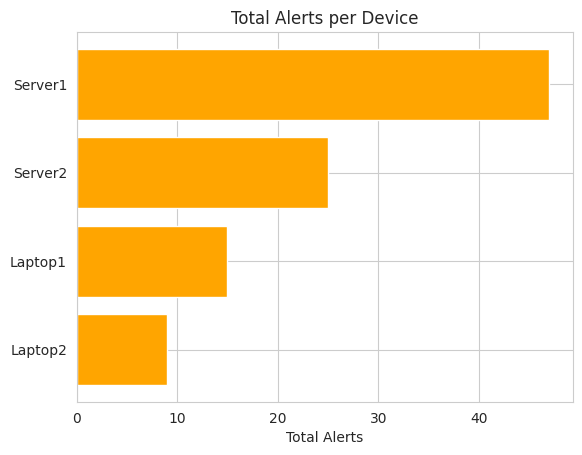

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "date": pd.date_range(start="2026-07-01", periods=10, freq="D"),
    "attack_type": ["ddos", "malware", "phishing", "ddos", "brute_force",
                     "malware", "ddos", "phishing", "brute_force", "malware"],
    "severity": ["High", "Critical", "Medium", "High", "Medium",
                  "Critical", "High", "Medium", "Low", "High"],
    "device": ["Server1", "Server2", "Laptop1", "Server1", "Laptop2",
                "Server2", "Server1", "Laptop1", "Laptop2", "Server2"],
    "alerts_count": [12, 5, 8, 15, 6, 9, 20, 7, 3, 11]
}
df = pd.DataFrame(data)
df.head()
device_totals = df.groupby("device")["alerts_count"].sum().sort_values()

plt.barh(device_totals.index, device_totals.values, color="orange")
plt.title("Total Alerts per Device")
plt.xlabel("Total Alerts")
plt.show()


**Question 10:**  Is there a pattern between attack type and severity level? Show it as a grouped count plot

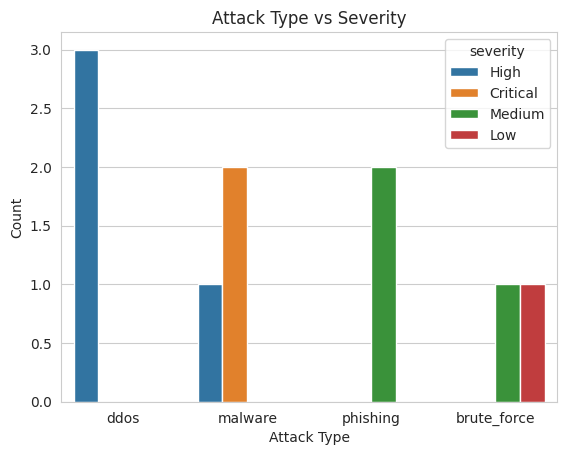

In [61]:
sns.countplot(data=df, x="attack_type", hue="severity")
plt.title("Attack Type vs Severity")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.show()


**Question 11:** What does the spread of alert counts look like? Show it as a boxplot.

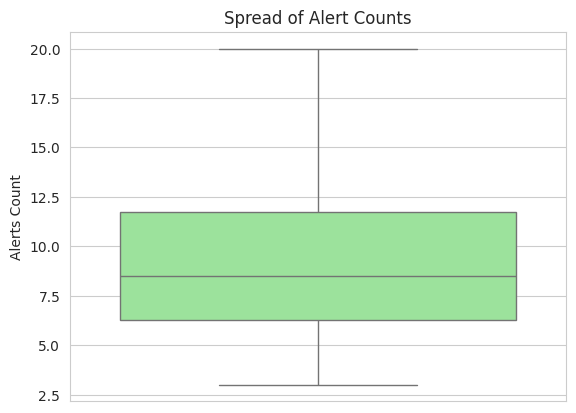

In [62]:
sns.boxplot(y=df["alerts_count"], color="lightgreen")
plt.title("Spread of Alert Counts")
plt.ylabel("Alerts Count")
plt.show()